In [61]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import json

In [62]:
dataverse_root = Path('/Users/meganbishop/moseq_dataverse')
keypoint_root = dataverse_root / 'keypoint_moseq'
manifest_path = keypoint_root / 'manifest_by_species.csv'
metadata_path = keypoint_root / 'metadata.json'
source_dir = dataverse_root / 'data_files'

manifest = pd.read_csv(manifest_path)
manifest = manifest[manifest['status'].isin(['ok', 'exists'])].copy()
manifest['subject'] = manifest['subject'].astype(str)

with open(metadata_path) as f:
    keypoint_metadata = json.load(f)

available_species = sorted(manifest['species_folder'].dropna().unique())
print('Available species folders:')
print('\n'.join(f'  - {s}' for s in available_species))

DATASET_CHOICES = {
    'size_normalized_coordinates': 'size_normalized_coordinates',
    'size_normalized_distances': 'size_normalized_distances',
    'egocentric_coordinates': 'coordinates',
    'egocentric_distances': 'distances',
}


Available species folders:
  - Mus_caroli
  - Mus_musculus
  - Mus_spretus
  - Peromyscus_californicus
  - Peromyscus_gossypinus
  - Peromyscus_leucopus
  - Peromyscus_maniculatus
  - Peromyscus_polionotus


In [63]:
def _recording_path(row):
    return dataverse_root / row['output_file']


def _source_path(row):
    return source_dir / f"{row['recording_id']}.hdf5"


def _samplerate(row):
    with h5py.File(_source_path(row), 'r') as f:
        return float(f['recording'].attrs['samplerate'])


def _slice_for(max_frames=None, stride=1):
    stop = None if max_frames is None else int(max_frames) * int(stride)
    return slice(0, stop, int(stride))


def species_subjects(species_name):
    species_manifest = manifest[manifest['species_folder'] == species_name]
    if species_manifest.empty:
        available = ', '.join(available_species)
        raise ValueError(f'Unknown species {species_name!r}. Available: {available}')
    return sorted(species_manifest['subject'].dropna().astype(str).unique())


def select_manifest(species_name, individual_ids=None):
    species_manifest = manifest[manifest['species_folder'] == species_name].copy()
    if species_manifest.empty:
        available = ', '.join(available_species)
        raise ValueError(f'Unknown species {species_name!r}. Available: {available}')

    if individual_ids is None:
        keep = species_subjects(species_name)
    elif isinstance(individual_ids, (str, int, float)):
        keep = [str(individual_ids)]
    else:
        keep = [str(x) for x in individual_ids]

    missing = sorted(set(keep) - set(species_subjects(species_name)))
    if missing:
        preview = ', '.join(species_subjects(species_name)[:10])
        raise ValueError(f'{species_name}: unknown individual(s) {missing}. First available: {preview}')

    return species_manifest[species_manifest['subject'].astype(str).isin(keep)].sort_values(
        ['subject', 'recording_id']
    )


def load_individual_trace(
    species_name,
    individual_id=None,
    dataset_name='size_normalized_coordinates',
    stride=1,
    max_frames_per_recording=None,
    dtype=np.float32,
):
    dataset = DATASET_CHOICES[dataset_name]
    subjects = species_subjects(species_name)
    if individual_id is None:
        individual_id = subjects[0]
    individual_id = str(individual_id)

    rows = select_manifest(species_name, individual_id)
    X_segments = []
    confidence_segments = []
    recording_ids = []
    samplerates = []
    segment_lengths = []
    slc = _slice_for(max_frames_per_recording, stride)

    for _, row in rows.iterrows():
        samplerates.append(_samplerate(row))
        with h5py.File(_recording_path(row), 'r') as f:
            values = f[dataset][slc]
            confidences = f['confidences'][slc]

        if values.ndim == 3:
            values = values.reshape(values.shape[0], values.shape[1] * values.shape[2])
        elif values.ndim != 2:
            raise ValueError(f'Expected 2D/3D dataset for {dataset}; got {values.shape}')

        X_segments.append(values.astype(dtype, copy=False))
        confidence_segments.append(confidences.astype(np.float32, copy=False))
        recording_ids.append(row['recording_id'])
        segment_lengths.append(values.shape[0])

    if len(set(samplerates)) != 1:
        raise ValueError(f'Multiple samplerates found for {species_name}/{individual_id}: {samplerates}')

    raw_fs = samplerates[0]
    fs = raw_fs / int(stride)
    return {
        'species_folder': species_name,
        'individual_id': individual_id,
        'dataset_name': dataset_name,
        'dataset': dataset,
        'X': np.concatenate(X_segments, axis=0),
        'confidences': np.concatenate(confidence_segments, axis=0),
        'recording_ids': recording_ids,
        'segment_lengths': np.array(segment_lengths, dtype=int),
        'raw_fs': raw_fs,
        'fs': fs,
        'stride': int(stride),
        'n_recordings': len(recording_ids),
    }


In [64]:
print(keypoint_metadata.keys())

dict_keys(['bodyparts', 'skeleton', 'keypoint_colors', 'skeleton_edge_colors', 'format', 'recording_dataset', 'confidence_dataset', 'source_coordinates_dataset', 'source_confidences_dataset', 'input_dir', 'aggregate_file', 'recordings_layout', 'species_manifest', 'species_folder_note', 'distance_dataset', 'distance_dtype', 'distance_pairs', 'size_normalized_coordinates_dataset', 'size_normalized_distances_dataset', 'size_normalized_source_dataset', 'size_normalized_distance_dtype'])


,species_index,species
0,0,Mus_caroli
1,1,Mus_musculus
2,2,Mus_spretus
3,3,Peromyscus_californicus
4,4,Peromyscus_gossypinus
5,5,Peromyscus_leucopus
6,6,Peromyscus_maniculatus
7,7,Peromyscus_polionotus


,species,individual_id,recording_id,source_path,source_frame
0,Mus_caroli,CAROLI-F-2L-741,24-11-20-13-48-38-086920,/Users/meganbishop/moseq_dataverse/data_files/...,16260
1,Peromyscus_californicus,38824.0,24-01-26-13-49-21-859142,/Users/meganbishop/moseq_dataverse/data_files/...,16780
2,Peromyscus_leucopus,37991.0,23-10-27-16-31-22-969909,/Users/meganbishop/moseq_dataverse/data_files/...,5300


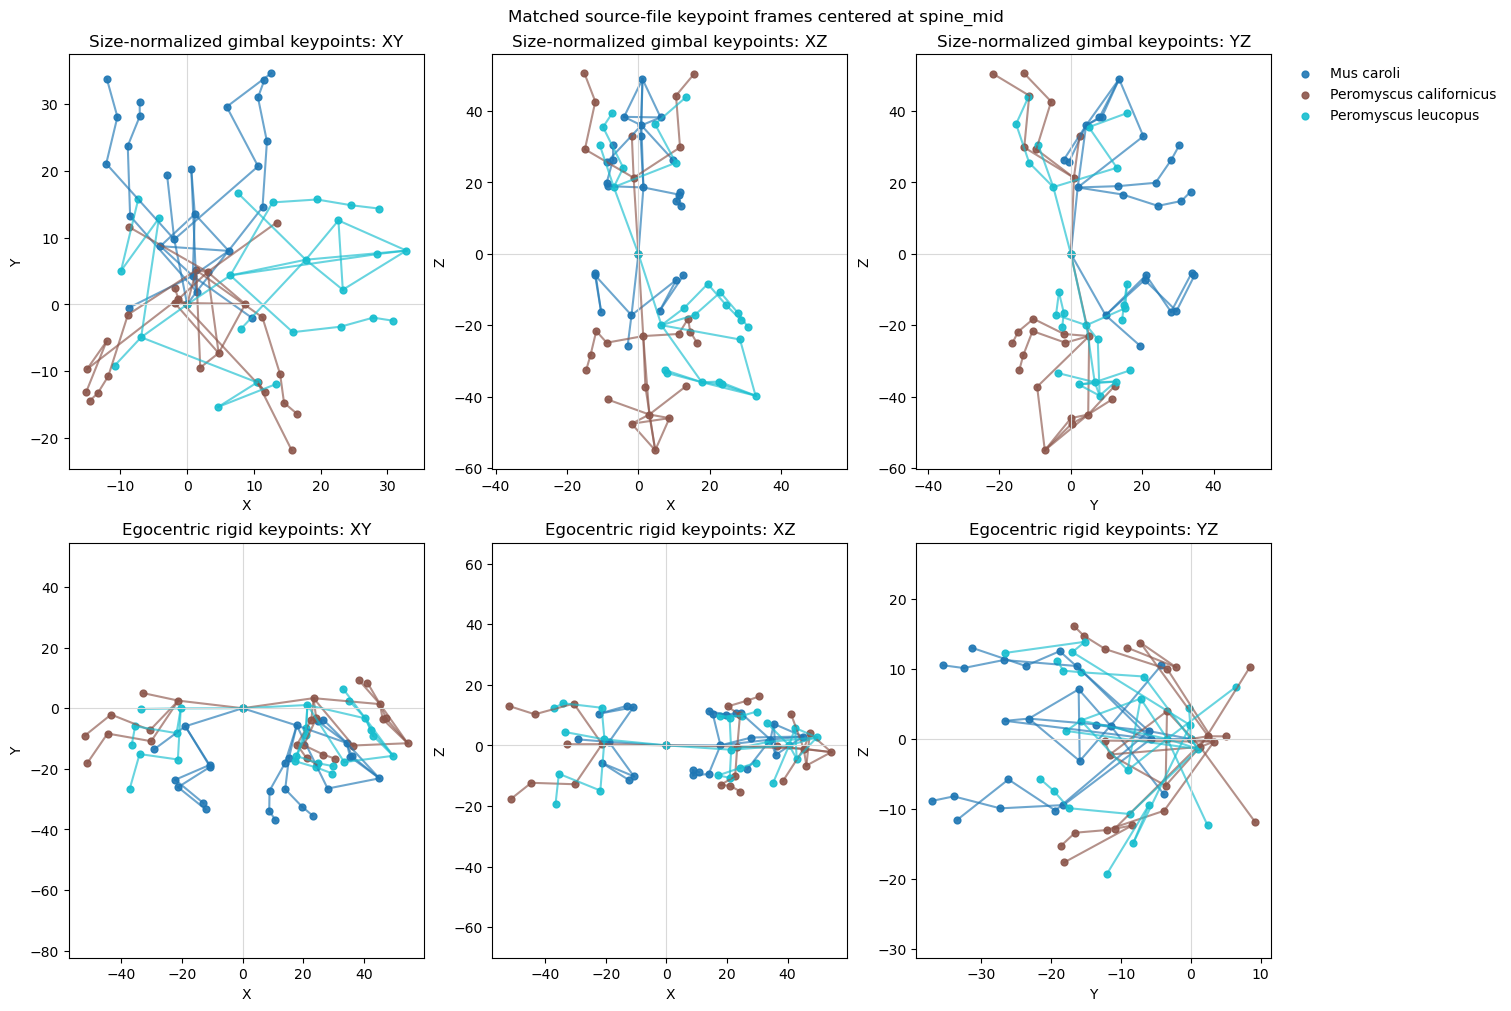

In [65]:
# Select species by index and compare matched source-file keypoint poses.
SPECIES_INDICES = [0, 3, 5]
INDIVIDUAL_INDEX = 0
RECORDING_INDEX = 0
MAX_FRAMES = 20000
FRAME_STRIDE = 20
MIN_CONFIDENCE = 0.5
CENTER_POSES_AT_SPINE_MID = True

SOURCE_COORDINATE_DATASETS = {
    'Size-normalized gimbal keypoints': 'recording/size_normalized_gimbal_keypoints',
    'Egocentric rigid keypoints': 'recording/egocentric_coordinates_rigid',
}
SOURCE_CONFIDENCE_DATASET = 'recording/confidences_3d'

species_index = pd.DataFrame({
    'species_index': np.arange(len(available_species)),
    'species': available_species,
})
display(species_index)

invalid_indices = [i for i in SPECIES_INDICES if i < 0 or i >= len(available_species)]
if invalid_indices:
    raise IndexError(f'Invalid SPECIES_INDICES: {invalid_indices}; valid range is 0 to {len(available_species) - 1}')
selected_species = [available_species[i] for i in SPECIES_INDICES]

bodyparts = list(keypoint_metadata['bodyparts'])
bodypart_index = {name: i for i, name in enumerate(bodyparts)}
skeleton = [
    (bodypart_index[a], bodypart_index[b])
    for a, b in keypoint_metadata['skeleton']
    if a in bodypart_index and b in bodypart_index
]


def selected_source_row(species_name):
    subjects = species_subjects(species_name)
    if INDIVIDUAL_INDEX >= len(subjects):
        raise IndexError(f'{species_name} has only {len(subjects)} individuals')
    individual_id = subjects[INDIVIDUAL_INDEX]
    rows = select_manifest(species_name, individual_id).reset_index(drop=True)
    if RECORDING_INDEX >= len(rows):
        raise IndexError(f'{species_name}/{individual_id} has only {len(rows)} recordings')
    return individual_id, rows.iloc[RECORDING_INDEX]


def load_matched_source_poses(species_name):
    individual_id, row = selected_source_row(species_name)
    path = _source_path(row)
    with h5py.File(path, 'r') as f:
        missing = [dataset for dataset in [*SOURCE_COORDINATE_DATASETS.values(), SOURCE_CONFIDENCE_DATASET] if dataset not in f]
        if missing:
            raise KeyError(f'{path} is missing source datasets: {missing}')
        n_frames = min([f[dataset].shape[0] for dataset in SOURCE_COORDINATE_DATASETS.values()] + [f[SOURCE_CONFIDENCE_DATASET].shape[0], MAX_FRAMES])
        frame_indices = np.arange(0, n_frames, FRAME_STRIDE, dtype=int)
        confidences = np.asarray(f[SOURCE_CONFIDENCE_DATASET][frame_indices], dtype=float)
        mean_confidence = np.nanmean(confidences, axis=1)
        valid_keypoint_counts = np.sum(confidences >= MIN_CONFIDENCE, axis=1)
        score = mean_confidence + valid_keypoint_counts
        sampled_position = int(np.nanargmax(score))
        source_frame = int(frame_indices[sampled_position])
        poses = {
            title: np.asarray(f[dataset][source_frame], dtype=float)
            for title, dataset in SOURCE_COORDINATE_DATASETS.items()
        }

    anchor_index = bodypart_index.get('spine_mid')
    if CENTER_POSES_AT_SPINE_MID and anchor_index is not None:
        poses = {title: pose - pose[anchor_index] for title, pose in poses.items()}
    return {
        'species': species_name,
        'individual_id': individual_id,
        'recording_id': str(row['recording_id']),
        'source_path': path,
        'source_frame': source_frame,
        'poses': poses,
    }


source_pose_results = [load_matched_source_poses(species) for species in selected_species]
display(pd.DataFrame([
    {key: value for key, value in result.items() if key != 'poses'}
    for result in source_pose_results
]))


def plot_pose_projection(ax, pose, dims, color, label):
    for a, b in skeleton:
        segment = pose[[a, b]][:, dims]
        if np.isfinite(segment).all():
            ax.plot(segment[:, 0], segment[:, 1], color=color, alpha=0.65, linewidth=1.5)
    valid = np.isfinite(pose[:, dims]).all(axis=1)
    ax.scatter(pose[valid, dims[0]], pose[valid, dims[1]], s=24, color=color, alpha=0.9, label=label)


views = [((0, 1), 'XY'), ((0, 2), 'XZ'), ((1, 2), 'YZ')]
colors = plt.cm.tab10(np.linspace(0, 1, len(source_pose_results)))
fig, axes = plt.subplots(len(SOURCE_COORDINATE_DATASETS), 3, figsize=(15, 5 * len(SOURCE_COORDINATE_DATASETS)), constrained_layout=True)
axes = np.asarray(axes).reshape(len(SOURCE_COORDINATE_DATASETS), 3)
for row_index, dataset_title in enumerate(SOURCE_COORDINATE_DATASETS):
    for ax, (dims, view_name) in zip(axes[row_index], views):
        for result, color in zip(source_pose_results, colors):
            plot_pose_projection(ax, result['poses'][dataset_title], dims, color, result['species'].replace('_', ' '))
        ax.axhline(0, color='0.85', linewidth=0.8)
        ax.axvline(0, color='0.85', linewidth=0.8)
        ax.set_title(f'{dataset_title}: {view_name}')
        ax.set_aspect('equal', adjustable='datalim')
        ax.set_xlabel('XYZ'[dims[0]])
        ax.set_ylabel('XYZ'[dims[1]])
axes[0, -1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
centering_note = ' centered at spine_mid' if CENTER_POSES_AT_SPINE_MID else ''
fig.suptitle(f'Matched source-file keypoint frames{centering_note}')
plt.show()


,dataset,species,individual_id,recording_id,n_keypoint_values,x_median,y_median,z_median,x_std,y_std,z_std
0,Size-normalized gimbal keypoints,Mus_caroli,CAROLI-F-2L-741,24-11-20-13-48-38-086920,22804,135.016014,109.811489,622.371643,115.002217,17.360826,131.998180
1,Size-normalized gimbal keypoints,Peromyscus_californicus,38824.0,24-01-26-13-49-21-859142,20905,-0.560923,-116.342697,550.324219,144.936310,137.851683,38.445805
2,Size-normalized gimbal keypoints,Peromyscus_leucopus,37991.0,23-10-27-16-31-22-969909,22264,-46.213882,56.155437,560.256439,117.801963,105.440430,25.633258
3,Egocentric rigid keypoints,Mus_caroli,CAROLI-F-2L-741,24-11-20-13-48-38-086920,22804,10.796701,-0.131675,0.083454,22.592163,10.525835,7.918626
4,Egocentric rigid keypoints,Peromyscus_californicus,38824.0,24-01-26-13-49-21-859142,20905,14.653768,-0.125275,0.083846,26.096921,10.632192,8.651881
5,Egocentric rigid keypoints,Peromyscus_leucopus,37991.0,23-10-27-16-31-22-969909,22264,11.009041,-0.318970,0.137408,22.838149,10.376188,8.350430


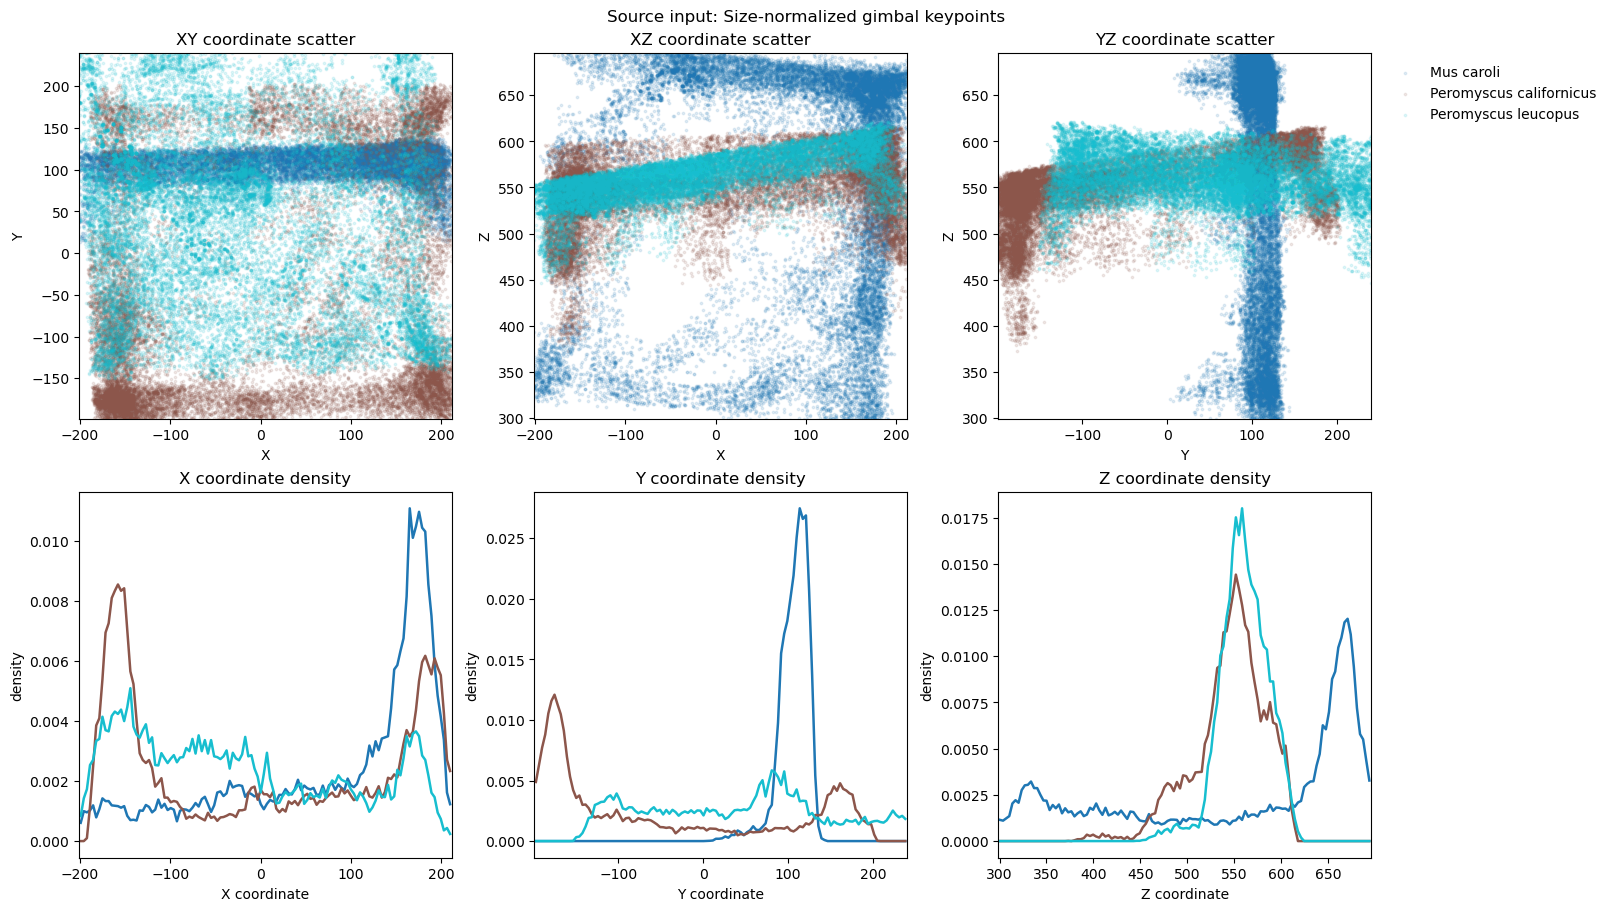

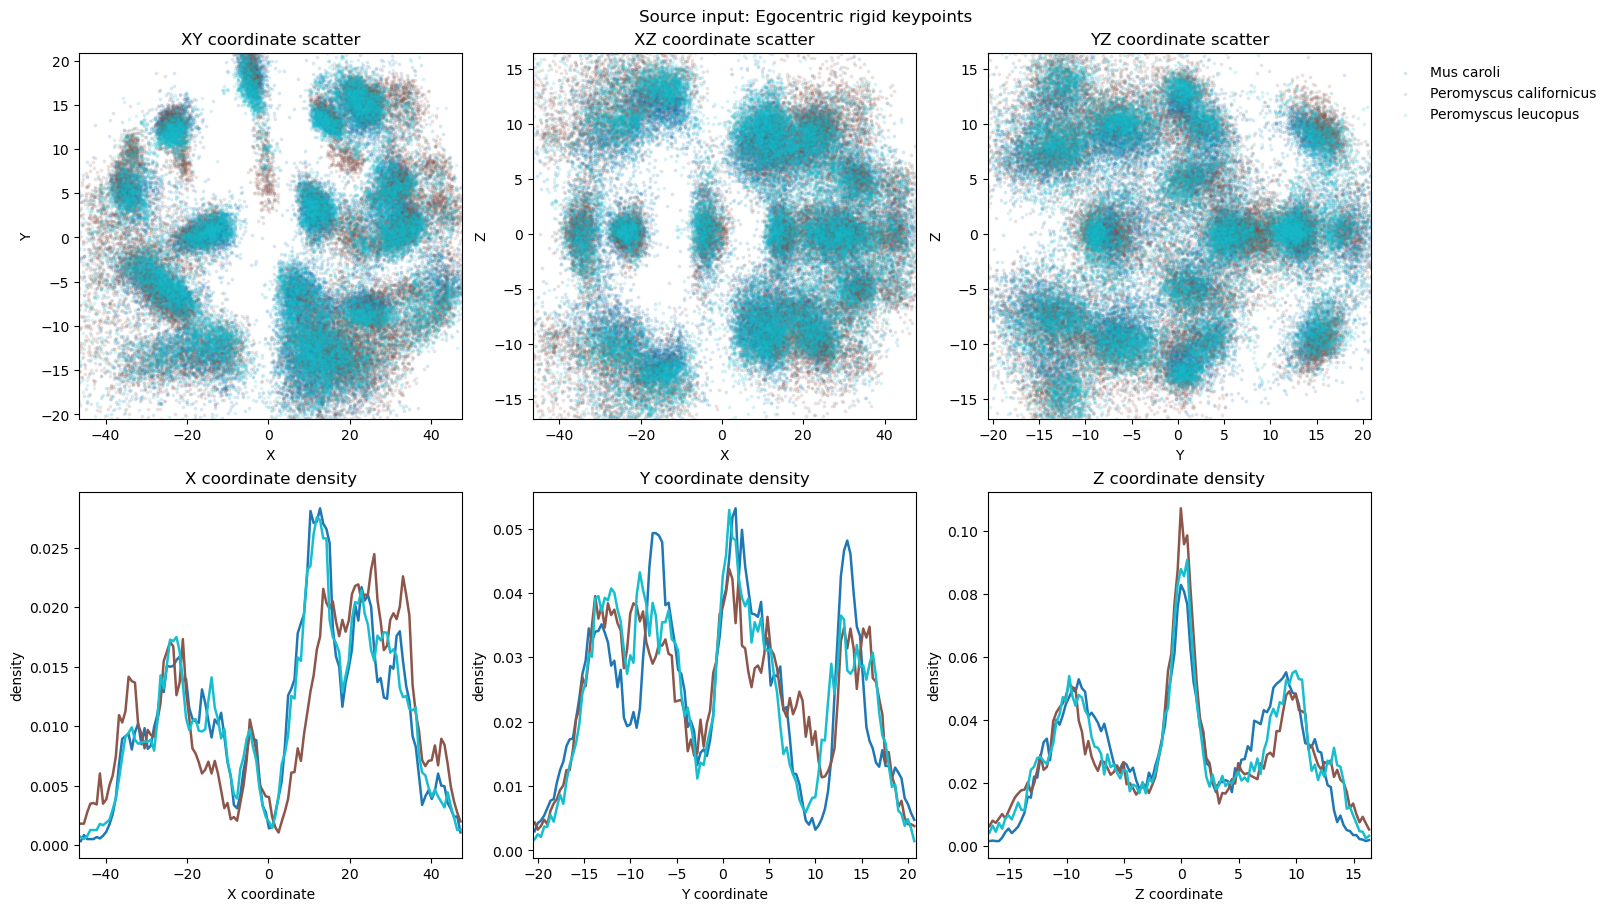

In [66]:
# Compare all sampled source-file X, Y, and Z values for both coordinate datasets.
MAX_SCATTER_POINTS_PER_SPECIES = 30000
DENSITY_BINS = 120
PLOT_RANDOM_SEED = 14


def load_source_coordinate_values(species_name, dataset):
    individual_id, row = selected_source_row(species_name)
    path = _source_path(row)
    with h5py.File(path, 'r') as f:
        stop = min(int(MAX_FRAMES), f[dataset].shape[0], f[SOURCE_CONFIDENCE_DATASET].shape[0])
        frame_indices = np.arange(0, stop, FRAME_STRIDE, dtype=int)
        coordinates = np.asarray(f[dataset][frame_indices], dtype=float)
        confidences = np.asarray(f[SOURCE_CONFIDENCE_DATASET][frame_indices], dtype=float)

    valid = (confidences >= MIN_CONFIDENCE) & np.isfinite(coordinates).all(axis=2)
    values = coordinates[valid]
    return {
        'species': species_name,
        'individual_id': individual_id,
        'recording_id': str(row['recording_id']),
        'source_path': path,
        'dataset': dataset,
        'values': values,
        'n_values': len(values),
    }


source_coordinate_values = {
    title: [load_source_coordinate_values(species, dataset) for species in selected_species]
    for title, dataset in SOURCE_COORDINATE_DATASETS.items()
}

source_coordinate_summary = pd.DataFrame([
    {
        'dataset': title,
        'species': result['species'],
        'individual_id': result['individual_id'],
        'recording_id': result['recording_id'],
        'n_keypoint_values': result['n_values'],
        'x_median': np.nanmedian(result['values'][:, 0]),
        'y_median': np.nanmedian(result['values'][:, 1]),
        'z_median': np.nanmedian(result['values'][:, 2]),
        'x_std': np.nanstd(result['values'][:, 0]),
        'y_std': np.nanstd(result['values'][:, 1]),
        'z_std': np.nanstd(result['values'][:, 2]),
    }
    for title, results in source_coordinate_values.items()
    for result in results
])
display(source_coordinate_summary)


def robust_axis_limits(results, dim, quantiles=(0.005, 0.995)):
    pooled = np.concatenate([result['values'][:, dim] for result in results])
    pooled = pooled[np.isfinite(pooled)]
    return tuple(np.quantile(pooled, quantiles))


rng = np.random.default_rng(PLOT_RANDOM_SEED)
scatter_pairs = [((0, 1), 'X', 'Y'), ((0, 2), 'X', 'Z'), ((1, 2), 'Y', 'Z')]
axis_names = ['X', 'Y', 'Z']

for dataset_title, results in source_coordinate_values.items():
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    for ax, (dims, x_name, y_name) in zip(axes[0], scatter_pairs):
        x_limits = robust_axis_limits(results, dims[0])
        y_limits = robust_axis_limits(results, dims[1])
        for result, color in zip(results, colors):
            values = result['values']
            n_plot = min(len(values), MAX_SCATTER_POINTS_PER_SPECIES)
            indices = rng.choice(len(values), size=n_plot, replace=False) if n_plot < len(values) else np.arange(len(values))
            sampled = values[indices]
            ax.scatter(sampled[:, dims[0]], sampled[:, dims[1]], s=3, alpha=0.12, color=color, label=result['species'].replace('_', ' '), rasterized=True)
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)
        ax.set_xlabel(x_name)
        ax.set_ylabel(y_name)
        ax.set_title(f'{x_name}{y_name} coordinate scatter')

    for dim, (ax, axis_name) in enumerate(zip(axes[1], axis_names)):
        limits = robust_axis_limits(results, dim)
        bins = np.linspace(limits[0], limits[1], DENSITY_BINS + 1)
        centers = (bins[:-1] + bins[1:]) / 2
        for result, color in zip(results, colors):
            values = result['values'][:, dim]
            density, _ = np.histogram(values[np.isfinite(values)], bins=bins, density=True)
            ax.plot(centers, density, color=color, linewidth=1.8, label=result['species'].replace('_', ' '))
        ax.set_xlim(limits)
        ax.set_xlabel(f'{axis_name} coordinate')
        ax.set_ylabel('density')
        ax.set_title(f'{axis_name} coordinate density')

    axes[0, 2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    fig.suptitle(f'Source input: {dataset_title}')
    plt.show()
